In [ ]:

import os, random, numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using", DEVICE)

Using cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_dir = "/content/drive/MyDrive/final_datasets_for_cnn_224/"

Mounted at /content/drive


In [ ]:
import shutil

In [ ]:
source_dir = "/content/drive/MyDrive/final_datasets_for_cnn_224"  # original dataset
target_dir = "/content/drive/MyDrive/dataset_balanced"  # balanced output

os.makedirs(target_dir, exist_ok=True)


classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]


counts = {}
for cls in classes:
    folder = os.path.join(source_dir, cls)
    counts[cls] = len([f for f in os.listdir(folder) if f.lower().endswith((".png",".jpg",".jpeg"))])

print("Class Image Counts:", counts)

# Minimum class size
min_count = min(counts.values())
print("Minimum class size:", min_count)

# Downsample all folders to min_count
for cls in classes:
    src = os.path.join(source_dir, cls)
    dest = os.path.join(target_dir, cls)
    os.makedirs(dest, exist_ok=True)

    images = [f for f in os.listdir(src) if f.lower().endswith((".png",".jpg",".jpeg"))]
    sampled = random.sample(images, min_count)

    for img in sampled:
        shutil.copy(os.path.join(src, img), os.path.join(dest, img))

print("Balanced dataset created at:", target_dir)

Class Image Counts: {'Soil': 3153, 'Healthy': 4149, 'MLB': 4254}
Minimum class size: 3153
Balanced dataset created at: /content/drive/MyDrive/dataset_balanced


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)


In [ ]:
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size   = int(0.15 * total_size)
test_size  = total_size - train_size - val_size

In [ ]:
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])


In [ ]:
batch_size = 64
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
valloader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
print("Classes:", full_dataset.classes)
print("Train size:", len(train_dataset), "Val size:", len(val_dataset), "Test size:", len(test_dataset))

Classes: ['Healthy', 'MLB', 'Soil']
Train size: 8089 Val size: 1733 Test size: 1734


In [ ]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(SmallCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # (3 → 32)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # (32 → 64)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)   # downsampling

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # (64 → 128)
        self.bn3 = nn.BatchNorm2d(128)

        self.gap = nn.AdaptiveAvgPool2d((4,4))
        self.fc1 = nn.Linear(2048, 256) # adjust if input ≠ 64x64
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 32 → 16
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 16 → 8
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 8 → 4
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
model = SmallCNN().to(DEVICE)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping(patience=5)

In [ ]:
epochs = 30
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(valloader)
    val_acc = 100 * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% "
          f"| Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

    # Adjust learning rate
    scheduler.step(val_loss)

    # Early stopping
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered 🚦")
        break

print("Training Finished ✅")

Epoch 1 | Train Loss: 0.3346, Acc: 86.29% | Val Loss: 0.1978, Acc: 91.75%
Epoch 2 | Train Loss: 0.2535, Acc: 90.60% | Val Loss: 0.2061, Acc: 91.40%
Epoch 3 | Train Loss: 0.2227, Acc: 91.46% | Val Loss: 0.1980, Acc: 91.86%
Epoch 4 | Train Loss: 0.1974, Acc: 92.53% | Val Loss: 0.1522, Acc: 94.29%
Epoch 5 | Train Loss: 0.1956, Acc: 92.35% | Val Loss: 0.1904, Acc: 91.11%
Epoch 6 | Train Loss: 0.1782, Acc: 93.48% | Val Loss: 0.1507, Acc: 94.00%
Epoch 7 | Train Loss: 0.1616, Acc: 94.00% | Val Loss: 0.1351, Acc: 94.46%
Epoch 8 | Train Loss: 0.1715, Acc: 93.67% | Val Loss: 0.1307, Acc: 94.75%
Epoch 9 | Train Loss: 0.1390, Acc: 94.40% | Val Loss: 0.1983, Acc: 91.86%
Epoch 10 | Train Loss: 0.1700, Acc: 93.46% | Val Loss: 0.1453, Acc: 93.88%
Epoch 11 | Train Loss: 0.1404, Acc: 94.34% | Val Loss: 0.1472, Acc: 94.23%
Epoch 12 | Train Loss: 0.1316, Acc: 95.20% | Val Loss: 0.1038, Acc: 95.61%
Epoch 13 | Train Loss: 0.1109, Acc: 95.81% | Val Loss: 0.1154, Acc: 95.38%
Epoch 14 | Train Loss: 0.1179, Acc

In [ ]:
save_path = "/content/drive/MyDrive/smallcnn_frozen.pth"
torch.save(model.state_dict(), save_path)
print("saved at:", save_path)

saved at: /content/drive/MyDrive/smallcnn_frozen.pth


In [ ]:
model = SmallCNN(num_classes=4)
model.load_state_dict(torch.load("/content/drive/MyDrive/smallcnn_frozen.pth"))
model.eval()

SmallCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gap): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=4, bias=True)
)

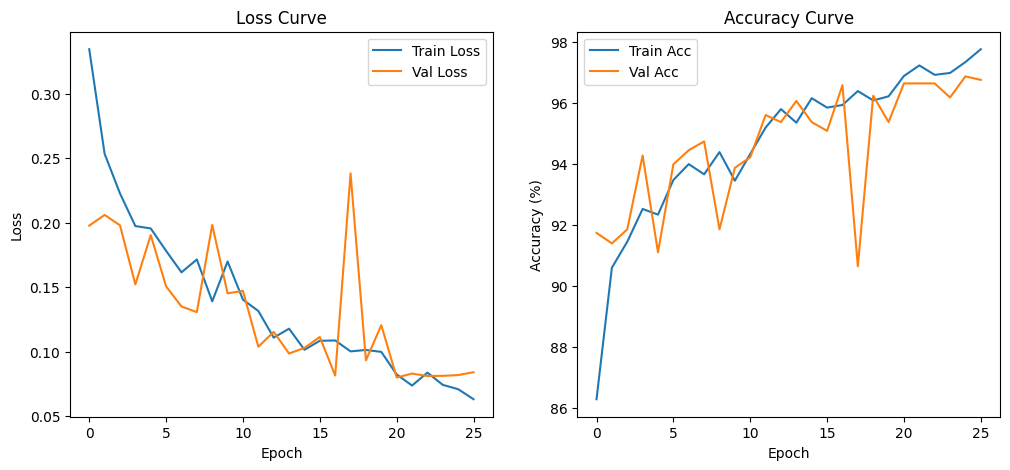

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SmallCNN(num_classes=4)
model.load_state_dict(torch.load("/content/drive/MyDrive/smallcnn_frozen.pth", map_location=DEVICE))
model.to(DEVICE)     # << IMPORTANT
model.eval()


SmallCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gap): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=4, bias=True)
)

In [ ]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 96.66%


In [ ]:
correct_imgs, wrong_imgs = [], []

model.eval()
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        for i in range(len(labels)):
            if preds[i] == labels[i] and len(correct_imgs) < 10:
                correct_imgs.append((inputs[i].cpu(), preds[i].item(), labels[i].item()))
            elif preds[i] != labels[i] and len(wrong_imgs) < 10:
                wrong_imgs.append((inputs[i].cpu(), preds[i].item(), labels[i].item()))

        if len(correct_imgs) >= 10 and len(wrong_imgs) >= 10:
            break

In [ ]:
import numpy as np

In [ ]:
def gradcam_visualize(model, image, true_label, pred_label, target_layer):
    model.eval()
    gradients, activations = [], []

    def save_gradient(grad):
        gradients.append(grad)

    def forward_hook(module, input, output):
        activations.append(output)
        output.register_hook(save_gradient)

    # hook the target layer
    hook = target_layer.register_forward_hook(forward_hook)

    # forward + backward
    image = image.unsqueeze(0).to(DEVICE)
    output = model(image)
    score = output[:, pred_label]
    score.backward()

    # compute Grad-CAM
    grads = gradients[0].mean(dim=(2,3), keepdim=True)
    cams = (activations[0] * grads).sum(dim=1).squeeze().cpu().detach().numpy()
    cams = np.maximum(cams, 0)
    cams = cams / cams.max()

    hook.remove()

    # convert image to numpy
    img_np = image.squeeze().permute(1,2,0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    # plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(8,4))

    # original image
    axes[0].imshow(img_np)
    axes[0].set_title("Original")
    axes[0].axis("off")

    # Grad-CAM overlay
    axes[1].imshow(img_np)
    axes[1].imshow(cams, cmap="jet", alpha=0.5)
    axes[1].set_title(f"Grad-CAM\nTrue: {true_label}, Pred: {pred_label}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
target_layer = model.conv3  # or last conv layer

# Correct predictions
for img, pred, true in correct_imgs:
    gradcam_visualize(model, img, true, pred, target_layer)

# Wrong predictions
for img, pred, true in wrong_imgs:
    gradcam_visualize(model, img, true, pred, target_layer)

# REMINDER:

FREEZE THE MODEL TO AVOID RETRAINING AND JUST USE THE MODEL TO EXTRACT WEIGHTS THAT WILL HELP WITH POST HOC TECHNIQUES.

In [ ]:
def integrated_gradients(model, input_tensor, target_idx=None, baseline=None, steps=50, device='cuda'):
    model.eval()
    if baseline is None:
        baseline = torch.zeros_like(input_tensor).to(device)
    input_tensor = input_tensor.to(device)
    diff = input_tensor - baseline
    total_grads = torch.zeros_like(input_tensor).to(device)

    for alpha in np.linspace(0, 1.0, steps):
        interp = baseline + alpha * diff
        interp.requires_grad_(True)
        out = model(interp)
        if target_idx is None:
            target_idx = out.argmax(dim=1).item()
        score = out[0, target_idx]
        model.zero_grad()
        score.backward(retain_graph=True)
        total_grads += interp.grad.data

    avg_grads = total_grads / steps  # (1,C,H,W)
    integrated_grads = diff * avg_grads  # (1,C,H,W)


    ig_map = integrated_grads.abs().sum(dim=1)[0].cpu().numpy()
    ig_map = (ig_map - ig_map.min()) / (ig_map.max() - ig_map.min() + 1e-8)
    return ig_map

* For production, use Captum (captum.attr.IntegratedGradients) — it's faster and numerically stable.

* **baseline** can be zero, blurred image, or mean image. Try different baselines.

In [ ]:
import scipy.ndimage as ndi

def smooth_and_normalize(map_np, sigma=3):
    sm = ndi.gaussian_filter(map_np, sigma=sigma)
    sm = (sm - sm.min()) / (sm.max() - sm.min() + 1e-8)
    return sm

Smoothing helps remove noise (Gaussian or morphological). Always scale to [0,1].


In [ ]:
def fuse_maps(map_g, map_ig, mode='weighted', alpha=0.6):
    if mode == 'weighted':
        return alpha*map_g + (1-alpha)*map_ig
    elif mode == 'mul':
        return map_g * map_ig
    elif mode == 'max':
        return np.maximum(map_g, map_ig)
    else:
        raise ValueError

* Additive (weighted): f = - α.Grad-CAM + β.IG - Good when maps are complementary. Apply Decision Trees or Convo 1x1 for better weight adjustments within the CNN.

* Multiplicative (elementwise): f = GCAM * IG. Emphasizes regions both methods agree on (conservative).

* Max: f = max(GCAM, IG) — permissive.

* Channel / layer fusion: fuse maps computed at different receptive fields (multi-scale).

**IDEA SKELETON** - Recurrent CNN Feedback Loop

In [ ]:
class FeedbackCNN(nn.Module):
    def __init__(self, base_cnn):
        super().__init__()
        self.encoder = base_cnn
        self.feedback = nn.Conv2d(512, 64, 1)  # project deeper -> shallow dims

    def forward(self, x, T=2):
        out = None
        feedback_map = 0
        for t in range(T):
            f1 = self.encoder.layer1(x)
            f2 = self.encoder.layer2(f1 + feedback_map)
            f3 = self.encoder.layer3(f2)
            out = self.encoder.classifier(f3)
            feedback_map = self.feedback(f3)
        return out

**Saliency or explainability refinement** — using feedback from deeper semantics to sharpen shallow edges.

**Data-driven augmentation loops** — fuse Grad-CAM maps from deeper layers and feed them back into earlier convolutions to modulate focus regions.

### **GOAL:**
Design a post-hoc feedback CNN that takes Grad-CAM or IG maps from each layer, fuses them, and feeds them back as attention masks for the next iteration — learning to “explain itself better” each pass.

| Choice              | Typical value                | Effect                                              |
| ------------------- | ---------------------------- | --------------------------------------------------- |
| Recurrent steps (T) | 2–4                          | More = better refinement but slower                 |
| Feedback type       | Additive / Concatenative     | Add preserves shape; concat expands channels        |
| Feedback source     | Last conv or pooled features | Controls semantic level                             |
| Feedback target     | Early conv / input embedding | Controls spatial modulation                         |
| Weight sharing      | Yes / No                     | If shared → recurrent CNN; if separate → 2-pass CNN |


#UPDATE:

In [ ]:
def integrated_gradients(model, input_tensor, target_class, baseline=None, steps=50):
    if baseline is None:
        baseline = torch.zeros_like(input_tensor)

    # scale inputs
    scaled_inputs = [
        (baseline + i/steps * (input_tensor - baseline)).clone().detach().requires_grad_(True)
        for i in range(steps+1)
    ]

    grads = []

    for scaled in scaled_inputs:
        output = model(scaled)
        loss = output[0, target_class]

        model.zero_grad()
        loss.backward()

        grads.append(scaled.grad.detach().clone())

    avg_grads = torch.mean(torch.stack(grads), dim=0)
    integrated = (input_tensor - baseline) * avg_grads
    return integrated

In [ ]:
images, labels = next(iter(testloader))

input_tensor = images[0].unsqueeze(0).to(DEVICE)   # (1,3,H,W)
target_class = labels[0].item()

input_tensor.requires_grad_(True)

ig_attr = integrated_gradients(model, input_tensor, target_class)
print(ig_attr.shape)

torch.Size([1, 3, 224, 224])


In [ ]:

input_tensor = input_tensor.requires_grad_(True)   # shape: (1,3,H,W)
target_class = 2                                   # whichever class index

ig_attr = integrated_gradients(model, input_tensor, target_class)
print(ig_attr.shape)

torch.Size([1, 3, 224, 224])


In [ ]:
def visualize(attr):
    attr = attr.squeeze().detach().cpu().numpy()   # <-- detach here
    attr = np.sum(np.abs(attr), axis=0)
    attr = (attr - attr.min()) / (attr.max() - attr.min())
    plt.imshow(attr, cmap="hot")
    plt.colorbar()
    plt.show()

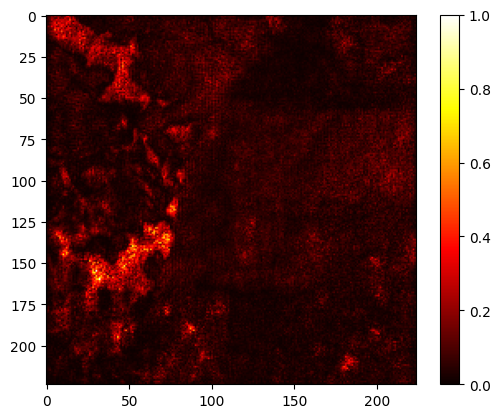

In [ ]:
visualize(ig_attr)

In [ ]:
!pip install captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 88.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-pyt

In [ ]:
from captum.attr import IntegratedGradients

def compute_ig(model, image, target_class):
    model.eval()
    ig = IntegratedGradients(model)

    # baseline = zero tensor
    baseline = torch.zeros_like(image)

    attributions, delta = ig.attribute(
        image.unsqueeze(0).to(DEVICE),
        baselines=baseline.unsqueeze(0).to(DEVICE),
        target=target_class,
        return_convergence_delta=True
    )

    return attributions.squeeze(0)

In [ ]:
def visualize_ig(attr):
    attr = attr.detach().cpu().numpy()     # tensor → numpy
    attr = np.sum(np.abs(attr), axis=0)    # sum over channels
    attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)

    plt.imshow(attr, cmap='hot')
    plt.colorbar()
    plt.title("Integrated Gradients")
    plt.axis("off")
    plt.show()

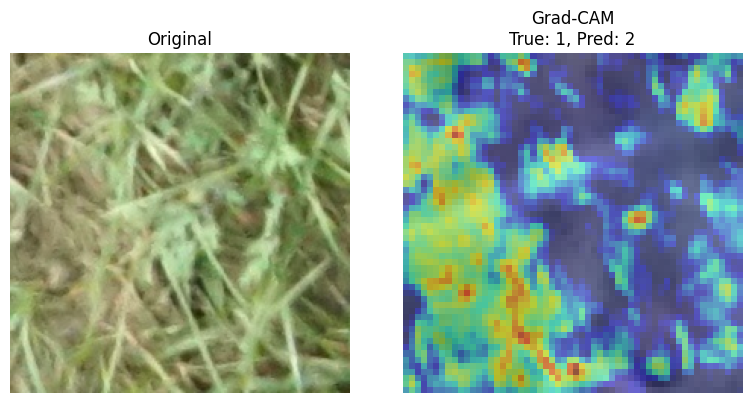

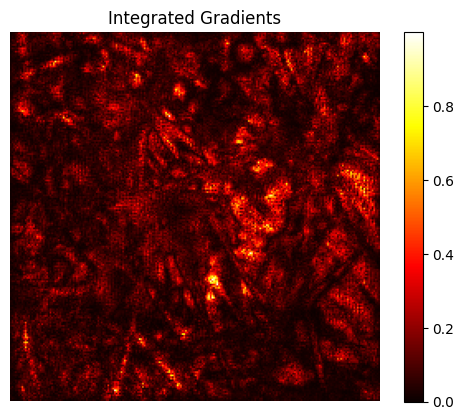

In [ ]:
gradcam_visualize(model, img, true, pred, target_layer)
ig_attr = compute_ig(model, img, pred)
visualize_ig(ig_attr)

In [ ]:
img_np = img.squeeze().permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

In [ ]:
gradients, activations = [], []
def save_gradient(grad):
        gradients.append(grad)

def forward_hook(module, input, output):
        activations.append(output)
        output.register_hook(save_gradient)

# hook the target layer
hook = target_layer.register_forward_hook(forward_hook)

# forward + backward
image = img.unsqueeze(0).to(DEVICE)
output = model(image)
score = output[:, pred]
score.backward()

# compute Grad-CAM
grads = gradients[0].mean(dim=(2,3), keepdim=True)
cams = (activations[0] * grads).sum(dim=1).squeeze().cpu().detach().numpy()
cams = np.maximum(cams, 0)
cams = cams / cams.max()

hook.remove()

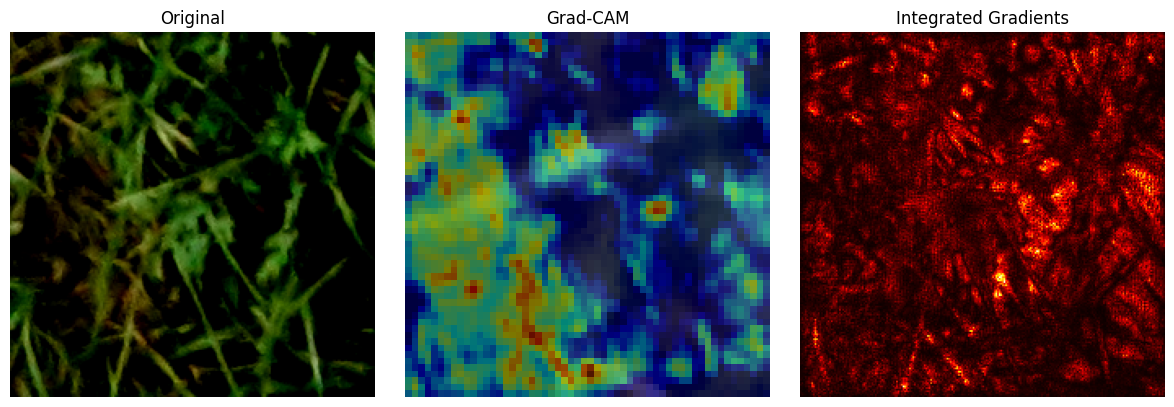

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

img_np = img.squeeze()                         # (3,224,224)
img_np = img_np.permute(1,2,0).cpu().numpy()   # → (224,224,3)

# Original image
axes[0].imshow(img_np)
axes[0].set_title("Original")
axes[0].axis("off")

# Grad-CAM (overlay on original)
axes[1].imshow(img_np)
axes[1].imshow(cams, cmap="jet", alpha=0.5)
axes[1].set_title("Grad-CAM")
axes[1].axis("off")

# Integrated Gradients (2D heatmap)
ig_attr_np = ig_attr.squeeze().cpu().detach().numpy()
ig_attr_np = np.sum(np.abs(ig_attr_np), axis=0)       # collapse channels
ig_attr_np = (ig_attr_np - ig_attr_np.min()) / (ig_attr_np.max() - ig_attr_np.min())

axes[2].imshow(ig_attr_np, cmap="hot")
axes[2].set_title("Integrated Gradients")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def overlay_integrated_gradients(img, ig_attr):
    # Convert CHW → HWC for image
    img_np = img.squeeze().permute(1,2,0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())  # normalize for display

    # Process IG tensor
    ig = ig_attr.squeeze().cpu().detach().numpy()   # (3,H,W)
    ig = np.sum(np.abs(ig), axis=0)                 # → (H,W)
    ig = (ig - ig.min()) / (ig.max() - ig.min())    # normalize 0-1

    # Plot overlay
    plt.figure(figsize=(5,5))
    plt.imshow(img_np)
    plt.imshow(ig, cmap="hot", alpha=0.45)
    plt.title("Integrated Gradients Overlay")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

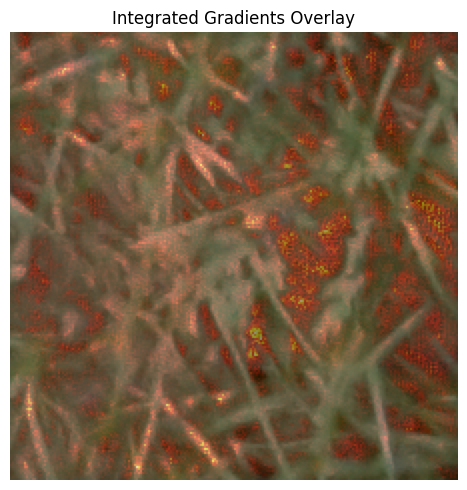

In [ ]:
overlay_integrated_gradients(img, ig_attr)

In [ ]:
import cv2

def fusion_heatmap(img, cams, ig_attr):
    # Resize GradCAM heatmap to match input image resolution
    cams_resized = cv2.resize(cams, (ig_attr.shape[1], ig_attr.shape[0]))

    # Normalize GradCAM
    gc = (cams_resized - cams_resized.min()) / (cams_resized.max() - cams_resized.min())

    # Normalize IG
    ig = (ig_attr - ig_attr.min()) / (ig_attr.max() - ig_attr.min())

    # Fusion heatmap (combined)
    fusion = gc * ig
    fusion = (fusion - fusion.min()) / (fusion.max() - fusion.min())

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.imshow(fusion, cmap="jet", alpha=0.45)
    plt.title("Fusion Grad-CAM + Integrated Gradients")
    plt.axis("off")
    plt.show()


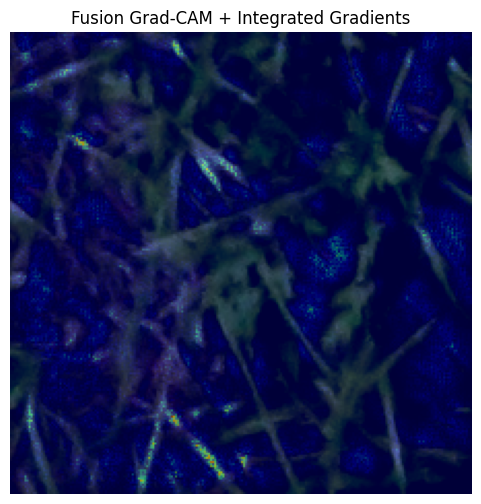

In [ ]:
fusion_heatmap(img_np, cams, ig_attr_np)